# **패션 MNIST 데이터에 대한 MLP 모델**

In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import r2_score
import tensorflow as tf; from tensorflow import keras
from keras.models import Model, Sequential
from keras.layers import Input, Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import random
from tensorflow.keras.callbacks import EarlyStopping

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 35.5 MB/s eta 0:00:00


데이터 불러오기(Fashion MNIST)

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
class_labels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker','Bag','Boot']

print("훈련용 이미지의 차원 =", x_train.shape)
print("훈련용 라벨의 차원 =", y_test.shape)
print("검증용 이미지의 차원 =", x_test.shape)
print("검증용 라벨의 차원 =", y_test.shape)

훈련용 이미지의 차원 = (60000, 28, 28)
훈련용 라벨의 차원 = (10000,)
검증용 이미지의 차원 = (10000, 28, 28)
검증용 라벨의 차원 = (10000,)


데이터 탐색

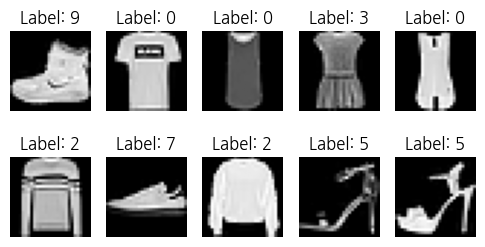

In [ ]:
# 처음 10개 이미지 출력
plt.figure(figsize=(6, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)  # 2행 5열의 서브플롯
    plt.imshow(x_train[i], cmap="gray")  # 흑백 이미지로 표시
    plt.axis("off")  # 축 숨기기
    plt.title(f"Label: {y_train[i]}")
plt.show()

데이터 전처리

In [ ]:
x_train=x_train/255; x_test=x_test/255   # 0~1 표준화 데이터전처리
x_test[0,15:19,15:19] # 첫 이미지

array([[0.45882353, 0.53333333, 0.61176471, 0.5254902 ],
       [0.5254902 , 0.56078431, 0.60392157, 0.64705882],
       [0.54509804, 0.52156863, 0.53333333, 0.62745098],
       [0.59215686, 0.60392157, 0.56078431, 0.58039216]])

모델 설정

In [ ]:
SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

model=Sequential([
      Input(shape=(28, 28)),
      Flatten(), # 28x28 차원 벡터로 변환
      Dense(32, activation='relu'),
      Dense(16, activation='relu'),
      Dense(16, activation='relu'),
      Dense(len(class_labels), activation='softmax')
      ])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,090 (101.91 KB)

 Trainable params: 26,090 (101.91 KB)

 Non-trainable params: 0 (0.00 B)

모델 학습

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True )
history=model.fit(x_train, y_train, epochs=50, validation_data=(x_test, y_test), verbose=1, callbacks=[early_stop])

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7895 - loss: 0.6099 - val_accuracy: 0.8382 - val_loss: 0.4675
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8508 - loss: 0.4257 - val_accuracy: 0.8458 - val_loss: 0.4412
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8635 - loss: 0.3863 - val_accuracy: 0.8505 - val_loss: 0.4294
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8713 - loss: 0.3623 - val_accuracy: 0.8508 - val_loss: 0.4279
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8772 - loss: 0.3444 - val_accuracy: 0.8558 - val_loss: 0.4134
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8815 - loss: 0.3307 - val_accuracy: 0.8552 - val_loss: 0.4126
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8849 - loss: 0.3202 - val_accuracy: 0.8561 - val_loss: 0.4096
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8872 - loss: 0.3122 - 

손실과 정확도 변화 시각화

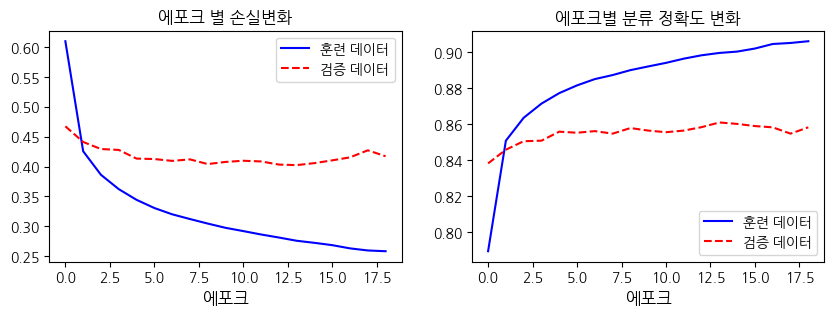

In [ ]:
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='훈련 데이터', color='blue', linestyle='-')
plt.plot(history.history['val_loss'], label='검증 데이터', color='red', linestyle='--')
plt.title('에포크 별 손실변화'); plt.xlabel('에포크', fontsize=12); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='훈련 데이터', color='blue', linestyle='-')
plt.plot(history.history['val_accuracy'], label='검증 데이터', color='red', linestyle='--')
plt.title('에포크별 분류 정확도 변화'); plt.xlabel('에포크', fontsize=12)
plt.legend(); plt.show()

학습된 모형의 성능 평가

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


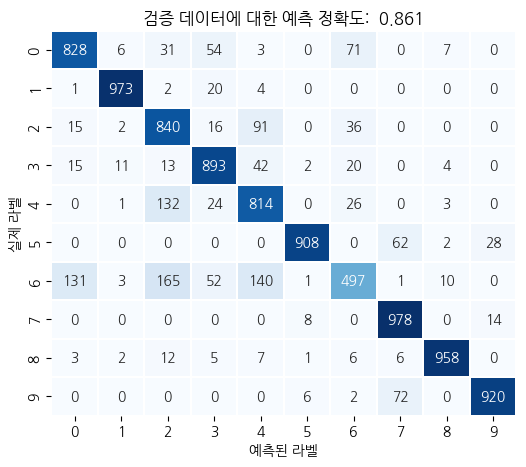

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

# 예측
y_prob=model.predict(x_test)      # 클래스별 예측 확률
y_pred=np.argmax(y_prob, axis=1)  # 확률이 가장 큰 클래스 인덱스

# 분류 정확도 계산
acc=accuracy_score(y_test, y_pred)

# 혼동행렬 시각화 (이전 코드 재활용)
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True,fmt="d", linewidths=0.1, cmap='Blues',cbar=None)

plt.ylabel('실제 라벨'); plt.xlabel('예측된 라벨')
plt.title(f'검증 데이터에 대한 예측 정확도:  {acc:.3f}')
plt.show()